# F3 - Notebook 02: Mediciones de tiempo y memoria

## Objetivo de este notebook

Este notebook contiene las mediciones de complejidad temporal y espacial de los algoritmos implementados en la Fase 3.

Está hecho en formato **100% Jupyter Notebook**, sin archivos `.py`.

## Qué se mide

- Tiempo promedio de ejecución.
- Tiempo mínimo.
- Tiempo máximo.
- Memoria pico utilizada.
- Comportamiento frente a distintos tamaños de muestra.

## Resultado esperado

Al ejecutar este notebook se obtendrá:

- Una tabla comparativa de mediciones.
- Gráficos de tiempo.
- Gráficos de memoria.
- Interpretación de complejidad.

In [1]:
from pathlib import Path
import time
import tracemalloc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Carga del dataset procesado

Se carga el dataset generado en Fase 2.

## Resultado esperado

El notebook debe confirmar que el archivo existe y mostrar filas/columnas.

In [3]:
# Busca automáticamente la raíz del proyecto subiendo carpetas
def encontrar_raiz_proyecto(nombre_repo="gym-fitness-analytics"):
    ruta_actual = Path.cwd().resolve()

    for ruta in [ruta_actual] + list(ruta_actual.parents):
        if ruta.name == nombre_repo:
            return ruta

    raise FileNotFoundError(
        f"No se pudo encontrar la raíz del proyecto '{nombre_repo}' desde {ruta_actual}"
    )


PROJECT_ROOT = encontrar_raiz_proyecto()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "gym_data_processed.csv"

print("Directorio actual:", Path.cwd().resolve())
print("Raíz del proyecto:", PROJECT_ROOT)
print("Ruta del dataset procesado:", DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset procesado en la ruta: {DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

print("Dataset procesado cargado correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

Directorio actual: C:\Users\warevalo\Documents\GitHub\gym-fitness-analytics\src\fase3
Raíz del proyecto: C:\Users\warevalo\Documents\GitHub\gym-fitness-analytics
Ruta del dataset procesado: C:\Users\warevalo\Documents\GitHub\gym-fitness-analytics\data\processed\gym_data_processed.csv
Dataset procesado cargado correctamente.
Filas: 3564
Columnas: 27


,country,year,region,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,...,periodo,gym_memberships_norm,total_health_club_revenue_usd_norm,number_of_gyms_norm,gdp_per_capita_usd_norm,population_total_norm,average_membership_cost_usd_norm,memberships_per_100k_norm,gyms_per_100k_norm,revenue_per_membership_usd_norm
0,Angola,2000,Africa,95521.0,0.3873,5731259.0,204.0,0.0059,0.5051,0.0470,...,pre_covid,0.000909,0.000066,0.003230,0.003299,0.011038,0.0,0.012043,0.034128,0.000001
1,Angola,2001,Africa,103840.0,0.3939,6230372.0,222.0,0.0062,0.5172,0.0496,...,pre_covid,0.000990,0.000071,0.003519,0.003080,0.011419,0.0,0.013051,0.036453,0.000001
2,Angola,2002,Africa,121093.0,0.4003,7265583.0,249.0,0.0070,0.5289,0.0522,...,pre_covid,0.001158,0.000084,0.003953,0.006461,0.011819,0.0,0.015678,0.040381,0.000001
3,Angola,2003,Africa,142783.0,0.4065,8566966.0,281.0,0.0080,0.5400,0.0548,...,pre_covid,0.001369,0.000099,0.004467,0.007438,0.012243,0.0,0.018908,0.044930,0.000001
4,Angola,2004,Africa,179615.0,0.4124,10776918.0,325.0,0.0097,0.5504,0.0574,...,pre_covid,0.001728,0.000125,0.005174,0.009747,0.012696,0.0,0.024573,0.051321,0.000001


## 2. Preparación mínima

Se seleccionan las columnas necesarias y se eliminan nulos puntuales.

## Resultado esperado

Un DataFrame `df_f3` disponible para mediciones.

In [4]:
columnas_f3 = [
    "country",
    "region",
    "year",
    "gym_penetration_rate",
    "memberships_per_100k",
    "gyms_per_100k",
    "revenue_per_membership_usd",
    "periodo"
]

faltantes = [col for col in columnas_f3 if col not in df.columns]

if faltantes:
    raise ValueError(f"Faltan columnas necesarias: {faltantes}")

df_f3 = df[columnas_f3].copy()

df_f3 = df_f3.dropna(
    subset=[
        "gym_penetration_rate",
        "memberships_per_100k",
        "gyms_per_100k"
    ]
)

print("Dataset preparado para mediciones.")
print("Filas:", df_f3.shape[0])
print("Columnas:", df_f3.shape[1])

Dataset preparado para mediciones.
Filas: 3564
Columnas: 8


## 3. Funciones de algoritmos a medir

Para que este notebook sea independiente y no dependa de archivos `.py`, se incluyen aquí las funciones necesarias.

## Resultado esperado

Las funciones quedan cargadas en memoria para ser medidas posteriormente.

In [5]:
def validar_columnas(df, columnas):
    faltantes = [col for col in columnas if col not in df.columns]
    if faltantes:
        raise ValueError(f"Faltan columnas requeridas: {faltantes}")


def calcular_ranking_paises(df, columna, top_n=10):
    if top_n <= 0:
        raise ValueError("top_n debe ser mayor que cero.")

    validar_columnas(df, ["country", "region", "year", columna])

    resultados = []

    for _, fila in df.iterrows():
        valor = fila[columna]
        if pd.notna(valor):
            resultados.append({
                "country": fila["country"],
                "region": fila["region"],
                "year": int(fila["year"]),
                "valor": float(valor)
            })

    resultados_ordenados = sorted(
        resultados,
        key=lambda x: x["valor"],
        reverse=True
    )

    return resultados_ordenados[:top_n]


def maximo_iterativo(valores):
    if len(valores) == 0:
        return None

    maximo = valores[0]

    for valor in valores[1:]:
        if valor > maximo:
            maximo = valor

    return maximo


def maximo_recursivo(valores):
    if len(valores) == 0:
        return None

    if len(valores) == 1:
        return valores[0]

    mitad = len(valores) // 2

    max_izq = maximo_recursivo(valores[:mitad])
    max_der = maximo_recursivo(valores[mitad:])

    if max_izq is None:
        return max_der

    if max_der is None:
        return max_izq

    return max(max_izq, max_der)


def maximo_recursivo_optimizado(valores, inicio=0, fin=None):
    if fin is None:
        fin = len(valores)

    if inicio >= fin:
        return None

    if fin - inicio == 1:
        return valores[inicio]

    mitad = (inicio + fin) // 2

    max_izq = maximo_recursivo_optimizado(valores, inicio, mitad)
    max_der = maximo_recursivo_optimizado(valores, mitad, fin)

    if max_izq is None:
        return max_der

    if max_der is None:
        return max_izq

    return max(max_izq, max_der)


def promedio_manual_por_region(df, columna):
    validar_columnas(df, ["region", columna])

    acumuladores = {}
    conteos = {}

    for _, fila in df.iterrows():
        region = fila["region"]
        valor = fila[columna]

        if pd.notna(region) and pd.notna(valor):
            region = str(region)

            if region not in acumuladores:
                acumuladores[region] = 0.0
                conteos[region] = 0

            acumuladores[region] += float(valor)
            conteos[region] += 1

    promedios = {}

    for region in acumuladores:
        if conteos[region] > 0:
            promedios[region] = acumuladores[region] / conteos[region]

    return promedios


def promedio_pandas_por_region(df, columna):
    validar_columnas(df, ["region", columna])
    return df.groupby("region")[columna].mean().sort_values(ascending=False)

## 4. Función para medir tiempo

Esta función ejecuta varias veces un algoritmo y calcula:

- Tiempo promedio.
- Tiempo mínimo.
- Tiempo máximo.

Usa `time.perf_counter()` porque es adecuado para medir intervalos de ejecución.

## Resultado esperado

Un diccionario con tiempos y resultado de la función medida.

In [6]:
def medir_tiempo(funcion, *args, repeticiones=5, **kwargs):
    """
    Mide el tiempo de ejecución promedio, mínimo y máximo de una función.
    """
    if repeticiones <= 0:
        raise ValueError("El número de repeticiones debe ser mayor que cero.")

    tiempos = []
    resultado = None

    for _ in range(repeticiones):
        inicio = time.perf_counter()
        resultado = funcion(*args, **kwargs)
        fin = time.perf_counter()

        tiempos.append(fin - inicio)

    return {
        "resultado": resultado,
        "tiempo_promedio": sum(tiempos) / len(tiempos),
        "tiempo_minimo": min(tiempos),
        "tiempo_maximo": max(tiempos),
        "repeticiones": repeticiones
    }

## 5. Función para medir memoria

Esta función utiliza `tracemalloc` para obtener:

- Memoria actual.
- Memoria pico.

La memoria pico es la más útil para comparar algoritmos, porque indica el mayor uso de memoria durante la ejecución.

## Resultado esperado

Un diccionario con memoria medida en bytes, KB y MB.

In [7]:
def medir_memoria(funcion, *args, **kwargs):
    """
    Mide uso de memoria actual y memoria pico durante la ejecución.
    """
    tracemalloc.start()

    resultado = funcion(*args, **kwargs)

    memoria_actual, memoria_pico = tracemalloc.get_traced_memory()

    tracemalloc.stop()

    return {
        "resultado": resultado,
        "memoria_actual_bytes": memoria_actual,
        "memoria_pico_bytes": memoria_pico,
        "memoria_pico_kb": memoria_pico / 1024,
        "memoria_pico_mb": memoria_pico / (1024 * 1024)
    }

## 6. Función combinada de tiempo y memoria

Esta función ejecuta medición de tiempo y luego medición de memoria.

## Resultado esperado

Un diccionario único con información temporal y espacial.

In [8]:
def medir_tiempo_y_memoria(funcion, *args, repeticiones=5, **kwargs):
    medicion_tiempo = medir_tiempo(
        funcion,
        *args,
        repeticiones=repeticiones,
        **kwargs
    )

    medicion_memoria = medir_memoria(
        funcion,
        *args,
        **kwargs
    )

    return {
        "resultado": medicion_tiempo["resultado"],
        "tiempo_promedio": medicion_tiempo["tiempo_promedio"],
        "tiempo_minimo": medicion_tiempo["tiempo_minimo"],
        "tiempo_maximo": medicion_tiempo["tiempo_maximo"],
        "memoria_pico_bytes": medicion_memoria["memoria_pico_bytes"],
        "memoria_pico_kb": medicion_memoria["memoria_pico_kb"],
        "memoria_pico_mb": medicion_memoria["memoria_pico_mb"],
        "repeticiones": repeticiones
    }

## 7. Construcción de registros comparativos

Esta función transforma cada medición en una fila para una tabla comparativa.

## Resultado esperado

Una estructura tipo diccionario que luego se convierte en DataFrame.

In [9]:
def construir_resumen_medicion(
    nombre_algoritmo,
    tipo_algoritmo,
    tamanio_muestra,
    medicion,
    complejidad_temporal,
    complejidad_espacial
):
    return {
        "algoritmo": nombre_algoritmo,
        "tipo": tipo_algoritmo,
        "n": tamanio_muestra,
        "tiempo_promedio_seg": medicion["tiempo_promedio"],
        "tiempo_minimo_seg": medicion["tiempo_minimo"],
        "tiempo_maximo_seg": medicion["tiempo_maximo"],
        "memoria_pico_kb": medicion["memoria_pico_kb"],
        "complejidad_temporal": complejidad_temporal,
        "complejidad_espacial": complejidad_espacial
    }

## 8. Definición de tamaños de muestra

Se prueban diferentes tamaños para observar cómo cambia el costo computacional.

## Resultado esperado

Una lista de tamaños válidos, por ejemplo:

`[100, 500, 1000, 5000, total]`

In [10]:
tamanios_base = [100, 500, 1000, 5000, len(df_f3)]

tamanios_muestra = []

for n in tamanios_base:
    if n <= len(df_f3) and n not in tamanios_muestra:
        tamanios_muestra.append(n)

print("Tamaños de muestra utilizados:", tamanios_muestra)

Tamaños de muestra utilizados: [100, 500, 1000, 3564]


## 9. Ejecución de mediciones

En esta sección se miden los algoritmos con cada tamaño de muestra.

## Algoritmos medidos

- Ranking iterativo.
- Máximo iterativo.
- Máximo recursivo con slicing.
- Máximo recursivo optimizado.
- Promedio manual por región.
- Promedio con Pandas.

## Resultado esperado

Un DataFrame llamado `df_mediciones` con tiempos, memoria y complejidad estimada.

In [11]:
resultados_mediciones = []

for n in tamanios_muestra:
    df_muestra = df_f3.head(n).copy()

    valores_muestra = (
        df_muestra["memberships_per_100k"]
        .dropna()
        .astype(float)
        .tolist()
    )

    medicion_ranking = medir_tiempo_y_memoria(
        calcular_ranking_paises,
        df_muestra,
        "memberships_per_100k",
        10,
        repeticiones=5
    )

    resultados_mediciones.append(
        construir_resumen_medicion(
            "Ranking iterativo",
            "Estructurado",
            n,
            medicion_ranking,
            "O(n log n)",
            "O(n)"
        )
    )

    medicion_max_iterativo = medir_tiempo_y_memoria(
        maximo_iterativo,
        valores_muestra,
        repeticiones=5
    )

    resultados_mediciones.append(
        construir_resumen_medicion(
            "Máximo iterativo",
            "Estructurado",
            n,
            medicion_max_iterativo,
            "O(n)",
            "O(1)"
        )
    )

    medicion_max_recursivo = medir_tiempo_y_memoria(
        maximo_recursivo,
        valores_muestra,
        repeticiones=5
    )

    resultados_mediciones.append(
        construir_resumen_medicion(
            "Máximo recursivo con slicing",
            "Recursivo",
            n,
            medicion_max_recursivo,
            "O(n)",
            "O(n)"
        )
    )

    medicion_max_recursivo_opt = medir_tiempo_y_memoria(
        maximo_recursivo_optimizado,
        valores_muestra,
        repeticiones=5
    )

    resultados_mediciones.append(
        construir_resumen_medicion(
            "Máximo recursivo optimizado",
            "Recursivo optimizado",
            n,
            medicion_max_recursivo_opt,
            "O(n)",
            "O(log n)"
        )
    )

    medicion_promedio_manual = medir_tiempo_y_memoria(
        promedio_manual_por_region,
        df_muestra,
        "gym_penetration_rate",
        repeticiones=5
    )

    resultados_mediciones.append(
        construir_resumen_medicion(
            "Promedio manual por región",
            "Estructurado",
            n,
            medicion_promedio_manual,
            "O(n)",
            "O(k)"
        )
    )

    medicion_promedio_pandas = medir_tiempo_y_memoria(
        promedio_pandas_por_region,
        df_muestra,
        "gym_penetration_rate",
        repeticiones=5
    )

    resultados_mediciones.append(
        construir_resumen_medicion(
            "Promedio Pandas por región",
            "Pandas groupby",
            n,
            medicion_promedio_pandas,
            "O(n) aprox.",
            "O(k)"
        )
    )

df_mediciones = pd.DataFrame(resultados_mediciones)

df_mediciones

,algoritmo,tipo,n,tiempo_promedio_seg,tiempo_minimo_seg,tiempo_maximo_seg,memoria_pico_kb,complejidad_temporal,complejidad_espacial
0,Ranking iterativo,Estructurado,100,0.007757,0.006211,0.010478,25.448242,O(n log n),O(n)
1,Máximo iterativo,Estructurado,100,0.000003,0.000003,0.000005,0.820312,O(n),O(1)
2,Máximo recursivo con slicing,Recursivo,100,0.000067,0.000044,0.000097,0.796875,O(n),O(n)
3,Máximo recursivo optimizado,Recursivo optimizado,100,0.000057,0.000057,0.000059,0.000000,O(n),O(log n)
4,Promedio manual por región,Estructurado,100,0.006191,0.005421,0.007606,21.500000,O(n),O(k)
5,Promedio Pandas por región,Pandas groupby,100,0.000492,0.000392,0.000824,9.424805,O(n) aprox.,O(k)
6,Ranking iterativo,Estructurado,500,0.029543,0.027946,0.030382,184.507812,O(n log n),O(n)
7,Máximo iterativo,Estructurado,500,0.000011,0.000010,0.000013,3.945312,O(n),O(1)
8,Máximo recursivo con slicing,Recursivo,500,0.000225,0.000221,0.000235,3.914062,O(n),O(n)
9,Máximo recursivo optimizado,Recursivo optimizado,500,0.000132,0.000130,0.000136,0.308594,O(n),O(log n)


## 10. Gráfico de tiempo promedio

Este gráfico permite observar cómo cambia el tiempo promedio de cada algoritmo al aumentar `n`.

## Resultado esperado

Un gráfico de líneas donde cada línea representa un algoritmo.

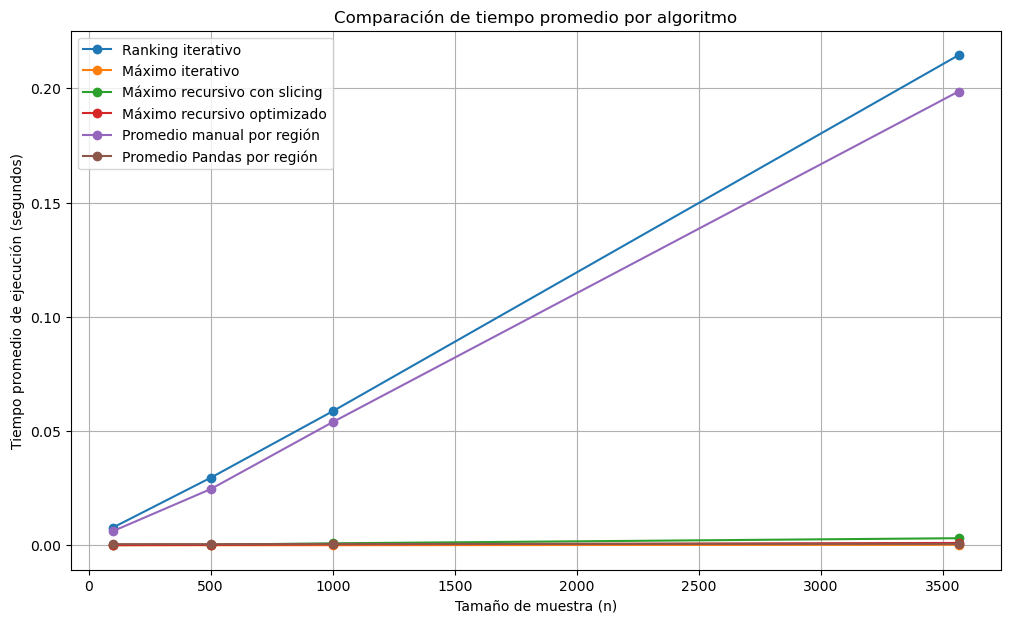

In [12]:
plt.figure(figsize=(12, 7))

for algoritmo in df_mediciones["algoritmo"].unique():
    datos_algoritmo = df_mediciones[df_mediciones["algoritmo"] == algoritmo]

    plt.plot(
        datos_algoritmo["n"],
        datos_algoritmo["tiempo_promedio_seg"],
        marker="o",
        label=algoritmo
    )

plt.xlabel("Tamaño de muestra (n)")
plt.ylabel("Tiempo promedio de ejecución (segundos)")
plt.title("Comparación de tiempo promedio por algoritmo")
plt.legend()
plt.grid(True)
plt.show()

## 11. Gráfico de memoria pico

Este gráfico compara el uso de memoria pico de cada algoritmo.

## Resultado esperado

Un gráfico donde se observe qué algoritmos utilizan más memoria.

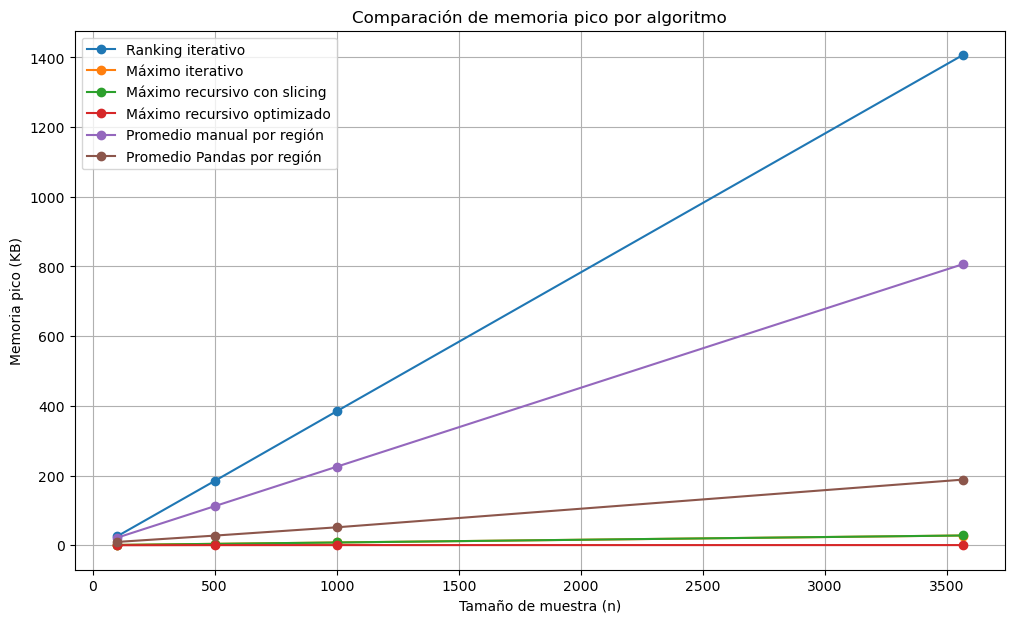

In [13]:
plt.figure(figsize=(12, 7))

for algoritmo in df_mediciones["algoritmo"].unique():
    datos_algoritmo = df_mediciones[df_mediciones["algoritmo"] == algoritmo]

    plt.plot(
        datos_algoritmo["n"],
        datos_algoritmo["memoria_pico_kb"],
        marker="o",
        label=algoritmo
    )

plt.xlabel("Tamaño de muestra (n)")
plt.ylabel("Memoria pico (KB)")
plt.title("Comparación de memoria pico por algoritmo")
plt.legend()
plt.grid(True)
plt.show()

## 12. Interpretación de resultados

Los resultados esperados deben mostrar diferencias entre algoritmos.

El ranking iterativo tiene complejidad `O(n log n)` porque requiere ordenar.

El máximo iterativo tiene complejidad temporal `O(n)` y espacial `O(1)`.

El máximo recursivo con slicing puede usar más memoria porque crea sublistas.

El máximo recursivo optimizado evita copias y debería ser más eficiente en memoria.

El promedio manual permite comprender el proceso algorítmico, mientras que Pandas entrega mayor legibilidad y optimización interna.